RQ1: How did the tone of media coverage of the Israel–Palestine conflict differ over time across the public broadcasters Tagesschau, ZDF, and PBS affiliates from October 2023 to December 2024?

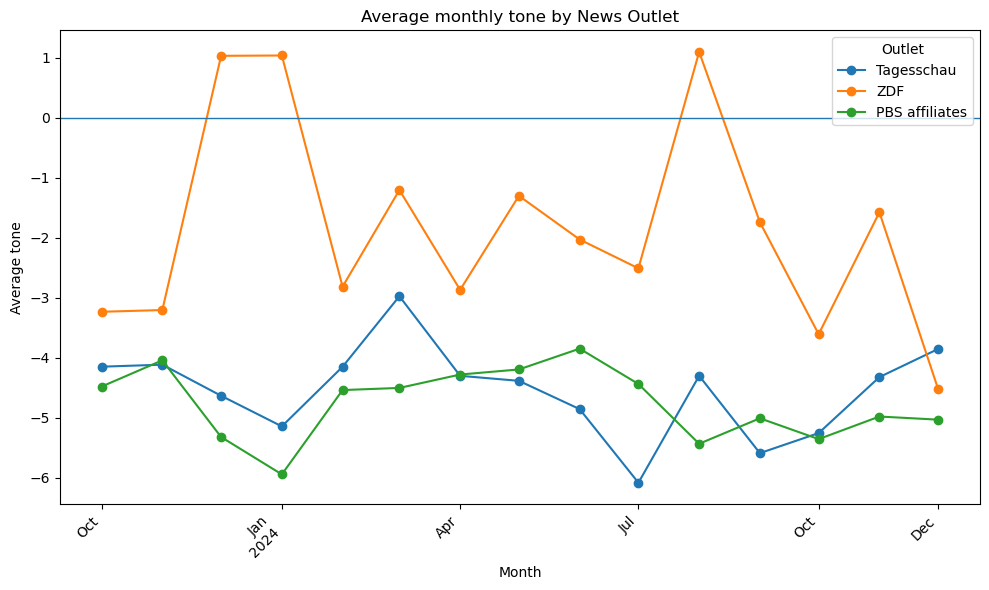

Total article counts by outlet:
Tagesschau: 1158
ZDF: 336
PBS affiliates: 1171


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

df = pd.read_csv(Path("tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full.csv"))

def first_tone(x):
    try:
        return float(str(x).split(",")[0])
    except:
        return np.nan

df["tone"] = df["V2Tone"].map(first_tone)
df["date"] = pd.to_datetime(df["DATE"].astype(str), format="%Y%m%d%H%M%S", errors="coerce")

pbs_affiliates = {"pbs.org", "kpbs.org", "nhpbs.org", "azpbs.org"}

def outlet_group(src):
    if src == "tagesschau.de":
        return "Tagesschau"
    elif src == "zdf.de":
        return "ZDF"
    elif src in pbs_affiliates:
        return "PBS affiliates"
    return None

df["outlet_group"] = df["SourceCommonName"].map(outlet_group)


url_col = "url" if "url" in df.columns else "DocumentIdentifier"

keywords = [
    "gaza", "palästina", "israel", "hamas", "palestine", "rafah",
    "Zwei-Staaten-Lösung", "two-state solution", "hamas-tunnel",
    "idf", "israel defense forces", "israelische verteidigungskräfte"
]

pattern = "|".join(keywords)

rq1 = df[
    df["outlet_group"].notna()
    & df[url_col].astype(str).str.contains(pattern, case=False, na=False, regex=True)
].copy()

rq1 = rq1.dropna(subset=["date", "tone"])
rq1 = rq1[(rq1["date"] >= "2023-10-08") & (rq1["date"] <= "2024-12-31")]

counts = rq1["outlet_group"].value_counts().to_dict()

rq1["month"] = rq1["date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    rq1.groupby(["month", "outlet_group"])["tone"]
    .mean()
    .reset_index(name="average_tone")
)


fig, ax = plt.subplots(figsize=(10, 6))

for outlet in ["Tagesschau", "ZDF", "PBS affiliates"]:
    sub = monthly[monthly["outlet_group"] == outlet]
    ax.plot(sub["month"], sub["average_tone"], marker="o", label=outlet)

ax.set_title("Average monthly tone by News Outlet")
ax.set_xlabel("Month")
ax.set_ylabel("Average tone")
ax.axhline(0, linewidth=1)
ax.legend(title="Outlet")

tick_dates = pd.to_datetime([
    "2023-10-01",
    "2024-01-01",
    "2024-04-01",
    "2024-07-01",
    "2024-10-01",
    "2024-12-01"
])

ax.set_xticks(tick_dates)

def custom_date_formatter(x, pos=None):
    dt = mdates.num2date(x)
    return dt.strftime("%b\n%Y") if dt.month == 1 else dt.strftime("%b")

ax.xaxis.set_major_formatter(plt.FuncFormatter(custom_date_formatter))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

print("Total article counts by outlet:")
for outlet in ["Tagesschau", "ZDF", "PBS affiliates"]:
    print(f"{outlet}: {counts.get(outlet, 0)}")

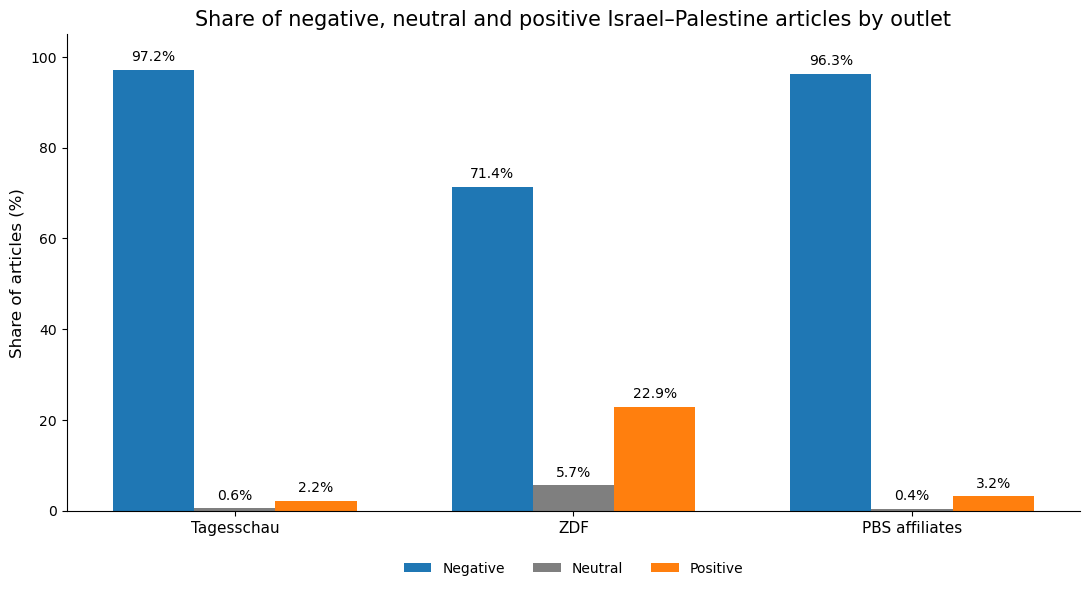

tone_category   Negative  Neutral  Positive
outlet_group                               
Tagesschau         97.15     0.60      2.25
ZDF                71.43     5.65     22.92
PBS affiliates     96.33     0.43      3.25


In [23]:
rq1 = df[df['outlet_group'].notna() & topic_mask].copy()
rq1 = rq1.dropna(subset=['date', 'tone'])
rq1 = rq1[(rq1['date'] >= '2023-10-08') & (rq1['date'] <= '2024-12-31')].copy()

def tone_category(x):
    if x < 0:
        return 'Negative'
    elif x > 0:
        return 'Positive'
    return 'Neutral'

rq1['tone_category'] = rq1['tone'].apply(tone_category)

shares = (
    rq1.groupby(['outlet_group', 'tone_category'])
      .size()
      .unstack(fill_value=0)
)

for col in ['Negative', 'Neutral', 'Positive']:
    if col not in shares.columns:
        shares[col] = 0

shares = shares[['Negative', 'Neutral', 'Positive']]
shares = shares.div(shares.sum(axis=1), axis=0) * 100
shares = shares.reindex(['Tagesschau', 'ZDF', 'PBS affiliates'])

fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(shares.index))
width = 0.24

colors = {
    'Negative': '#1f77b4',
    'Neutral':  '#7f7f7f',
    'Positive': '#ff7f0e'
}

bars_neg = ax.bar(x - width, shares['Negative'], width, label='Negative', color=colors['Negative'])
bars_neu = ax.bar(x,         shares['Neutral'],  width, label='Neutral',  color=colors['Neutral'])
bars_pos = ax.bar(x + width, shares['Positive'], width, label='Positive', color=colors['Positive'])

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.1f}%',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=10
        )

add_labels(bars_neg)
add_labels(bars_neu)
add_labels(bars_pos)

ax.set_title('Share of negative, neutral and positive Israel–Palestine articles by outlet', fontsize=15)
ax.set_ylabel('Share of articles (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(shares.index, fontsize=11)
ax.set_ylim(0, 105)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(shares.round(2))

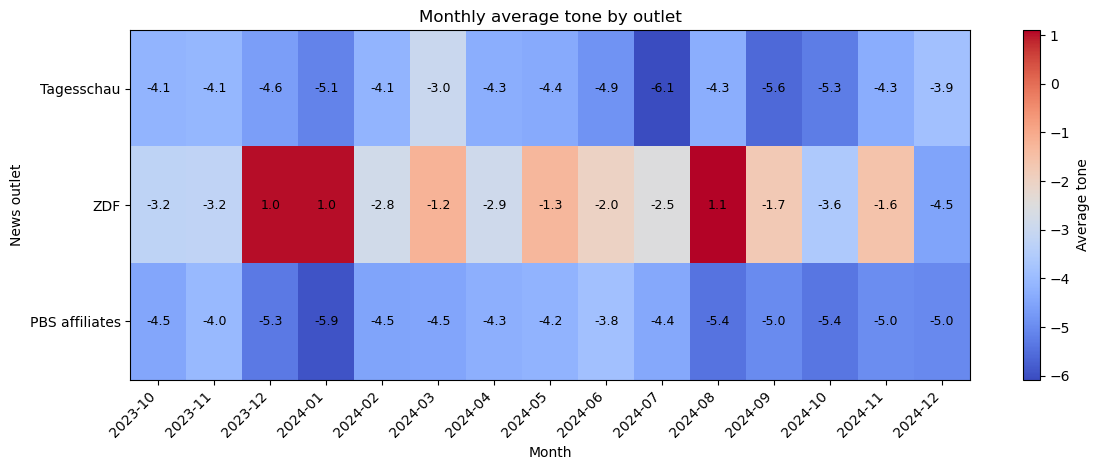

In [25]:
rq1['month'] = rq1['date'].dt.to_period('M').astype(str)

heatmap_data = (
    rq1.groupby(['outlet_group', 'month'])['tone']
       .mean()
       .reset_index()
       .pivot(index='outlet_group', columns='month', values='tone')
)

heatmap_data = heatmap_data.reindex(['Tagesschau', 'ZDF', 'PBS affiliates'])
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)

fig, ax = plt.subplots(figsize=(12, 4.8))

im = ax.imshow(heatmap_data, aspect='auto', cmap='coolwarm', interpolation='nearest')

ax.set_title('Monthly average tone by outlet')
ax.set_xlabel('Month')
ax.set_ylabel('News outlet')

ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha='right')

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha='center', va='center', color='black', fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Average tone')

plt.tight_layout()
plt.show()

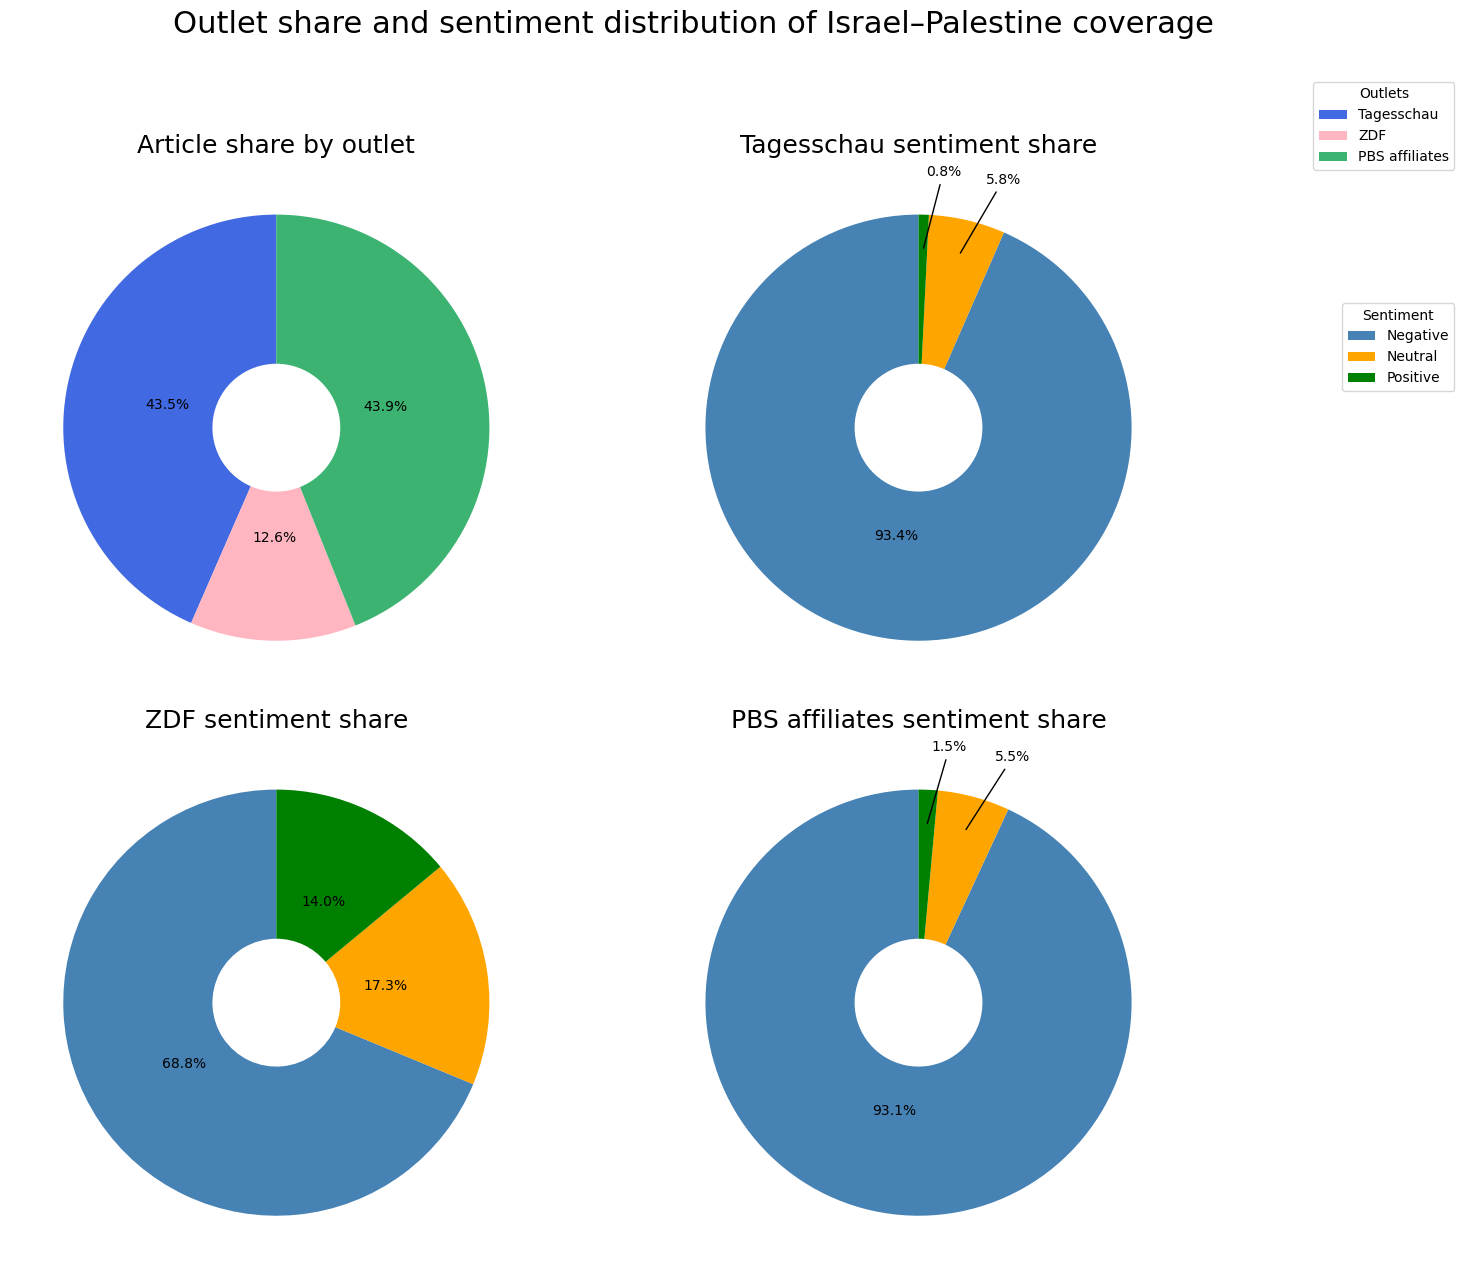

In [29]:
from matplotlib.patches import Patch

def donut_with_small_slice_annotations(
    ax, values, labels, colors, title,
    startangle=90, width=0.7, small_threshold=6
):
    wedges, _ = ax.pie(
        values,
        labels=None,
        startangle=startangle,
        colors=colors,
        wedgeprops=dict(width=width)
    )

    total = sum(values)

    for wedge, value, label in zip(wedges, values, labels):
        pct = 100 * value / total if total > 0 else 0

        angle = (wedge.theta2 + wedge.theta1) / 2
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))

        if pct > small_threshold:
            ax.text(
                0.52 * x,
                0.52 * y,
                f"{pct:.1f}%",
                ha='center',
                va='center',
                fontsize=10
            )
        else:
            x_text = 1.38 * x
            y_text = 1.38 * y

            if y > 0.75:
                y_text -= 0.18
            if y < -0.75:
                y_text += 0.10

            ax.annotate(
                f"{pct:.1f}%",
                xy=(0.83 * x, 0.83 * y),
                xytext=(x_text, y_text),
                ha='left' if x >= 0 else 'right',
                va='center',
                fontsize=10,
                arrowprops=dict(arrowstyle='-', lw=1)
            )

    ax.set_title(title, fontsize=18)

donut_df = rq1.copy()

def tone_category(x):
    if x < -1:
        return 'Negative'
    elif x > 1:
        return 'Positive'
    return 'Neutral'

donut_df['tone_category'] = donut_df['tone'].apply(tone_category)

outlet_counts = donut_df['outlet_group'].value_counts().reindex(
    ['Tagesschau', 'ZDF', 'PBS affiliates'],
    fill_value=0
)

def sentiment_share(data, outlet_name):
    return (
        data[data['outlet_group'] == outlet_name]['tone_category']
        .value_counts(normalize=True)
        .reindex(['Negative', 'Neutral', 'Positive'], fill_value=0) * 100
    )

tagesschau_sentiment = sentiment_share(donut_df, 'Tagesschau')
zdf_sentiment = sentiment_share(donut_df, 'ZDF')
pbs_sentiment = sentiment_share(donut_df, 'PBS affiliates')

outlet_colors = ['royalblue', 'lightpink', 'mediumseagreen']
sentiment_colors = ['steelblue', 'orange', 'green']

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

fig.suptitle(
    'Outlet share and sentiment distribution of Israel–Palestine coverage',
    fontsize=22,
    y=0.98
)

donut_with_small_slice_annotations(
    axes[0, 0],
    outlet_counts.values,
    outlet_counts.index.tolist(),
    outlet_colors,
    'Article share by outlet'
)

donut_with_small_slice_annotations(
    axes[0, 1],
    tagesschau_sentiment.values,
    tagesschau_sentiment.index.tolist(),
    sentiment_colors,
    'Tagesschau sentiment share'
)

donut_with_small_slice_annotations(
    axes[1, 0],
    zdf_sentiment.values,
    zdf_sentiment.index.tolist(),
    sentiment_colors,
    'ZDF sentiment share'
)

donut_with_small_slice_annotations(
    axes[1, 1],
    pbs_sentiment.values,
    pbs_sentiment.index.tolist(),
    sentiment_colors,
    'PBS affiliates sentiment share'
)

outlet_legend = [
    Patch(facecolor='royalblue', label='Tagesschau'),
    Patch(facecolor='lightpink', label='ZDF'),
    Patch(facecolor='mediumseagreen', label='PBS affiliates')
]

sentiment_legend = [
    Patch(facecolor='steelblue', label='Negative'),
    Patch(facecolor='orange', label='Neutral'),
    Patch(facecolor='green', label='Positive')
]

fig.legend(
    handles=outlet_legend,
    loc='upper right',
    bbox_to_anchor=(0.98, 0.93),
    title='Outlets'
)

fig.legend(
    handles=sentiment_legend,
    loc='upper right',
    bbox_to_anchor=(0.98, 0.76),
    title='Sentiment'
)

plt.tight_layout(rect=[0, 0, 0.88, 0.93])
plt.show()